In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
housing = fetch_california_housing()
print(housing)
df = pd.DataFrame(housing.data, columns = housing.feature_names)
df
column = 'AveRooms'

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [4]:
#Calculate q1 adn q3 

q1 = df[column].quantile(0.25)
q3 = df[column].quantile(0.75)

#2: Calculate the Interquartile Range
IQR = q3 -q1

#3: Define the lower and upper bound
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print(f"Column: {column}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")




Column: AveRooms
IQR: 1.61
Lower Bound: 2.02 | Upper Bound: 8.47


Total Rosw: 20640
Outliers Rows: 511


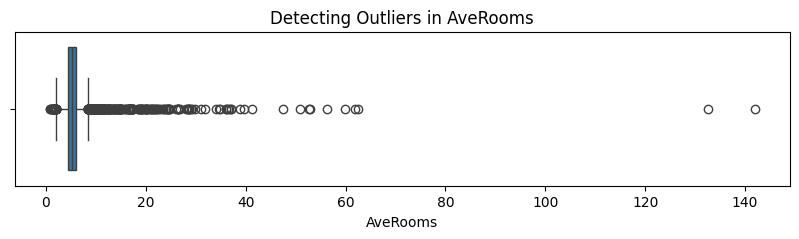

In [5]:
outliers = df[(df[column]<lower_bound) | (df[column]>upper_bound )]
print(f"Total Rosw: {len(df)}")
print(f"Outliers Rows: {len(outliers)}")
plt.figure(figsize=(10,2))
sns.boxplot(x=df[column])
plt.title(f"Detecting Outliers in {column}")
plt.show()


In [6]:
df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
print(f"SHape BEfore: {df.shape}")
print(f"shape after: {df_cleaned.shape}")

SHape BEfore: (20640, 8)
shape after: (20129, 8)


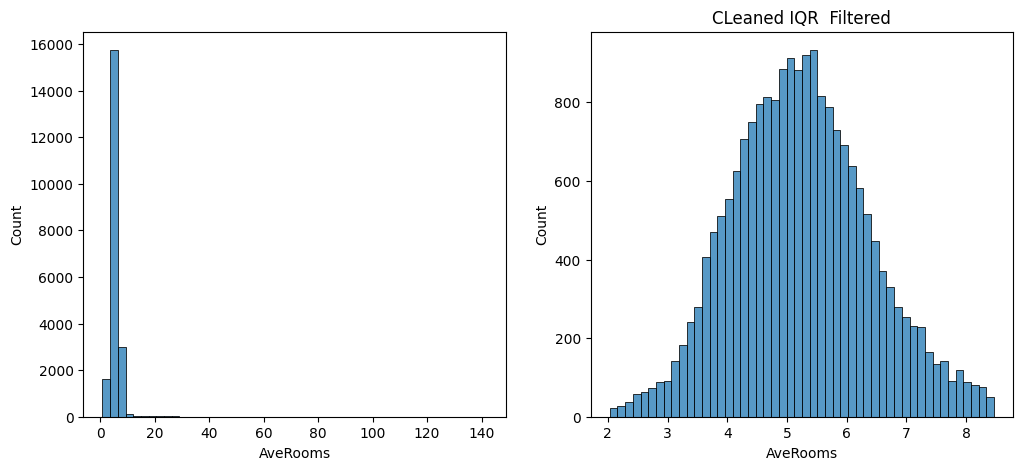

In [7]:
fig, ax = plt.subplots(1,2, figsize= (12,5))
sns.histplot(df[column], bins=50 , ax=ax[0])

set_title = ("Original with OUtlier")
sns.histplot(df_cleaned[column], bins = 50, ax = ax[1]).set_title("CLeaned IQR  Filtered")
plt.show()


In [8]:
column1 = "AveBedrms"

In [9]:
#Calculate q1 adn q3 

q1 = df[column1].quantile(0.25)
q3 = df[column1].quantile(0.75)

#2: Calculate the Interquartile Range
IQR = q3 -q1

#3: Define the lower and upper bound
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print(f"Column: {column1}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")




Column: AveBedrms
IQR: 0.09
Lower Bound: 0.87 | Upper Bound: 1.24


Total Rosw: 20640
Outliers Rows: 1424


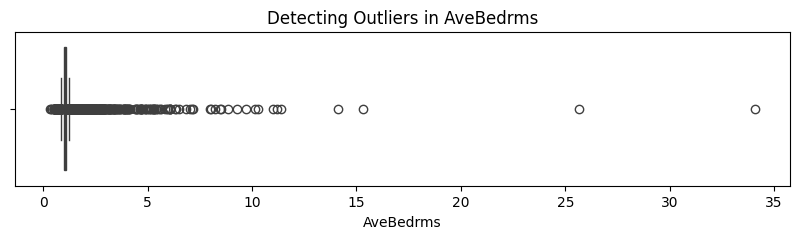

In [10]:
outliers = df[(df[column1]<lower_bound) | (df[column1]>upper_bound )]
print(f"Total Rosw: {len(df)}")
print(f"Outliers Rows: {len(outliers)}")
plt.figure(figsize=(10,2))
sns.boxplot(x=df[column1])
plt.title(f"Detecting Outliers in {column1}")
plt.show()

In [11]:
df_cleaned_new = df[(df[column1] >= lower_bound) & (df[column1] <= upper_bound)]
print(f"SHape BEfore: {df.shape}")
print(f"shape after: {df_cleaned_new.shape}")

SHape BEfore: (20640, 8)
shape after: (19216, 8)


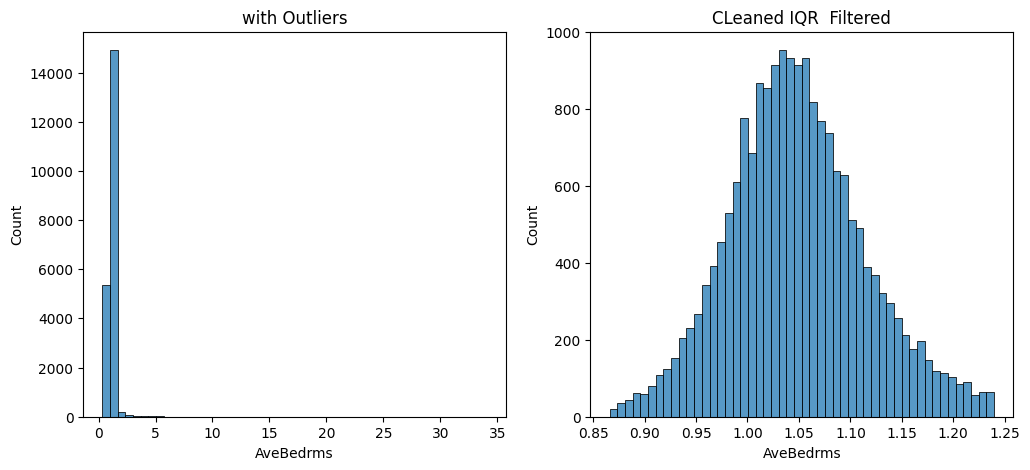

In [12]:
fig, ax = plt.subplots(1,2, figsize= (12,5))
sns.histplot(df[column1], bins=50 , ax=ax[0]).set_title("with Outliers")

set_title = ("Original with OUtlier")
sns.histplot(df_cleaned_new[column1], bins = 50, ax = ax[1]).set_title("CLeaned IQR  Filtered")
plt.show()
